# 05 - Évaluation Walk-Forward et Stratégie
## BTC Multivariate Forecast
### Étudiant B - Phase 2

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import des modules
import sys
sys.path.append('..')
from src.models.arima import ARIMAModel
from src.models.var import VARModel
from src.models.regression import RegressionModel
from src.models.random_forest import RandomForestModel
from src.evaluation.walk_forward import WalkForwardValidator
from src.evaluation.backtest import StrategyBacktester
from src.evaluation.metrics import compare_models

# Configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [2]:
# Chargement des données
X = pd.read_csv('../data/processed/X_train.csv', index_col=0, parse_dates=True)
y = pd.read_csv('../data/processed/y_train.csv', index_col=0, parse_dates=True).squeeze()

# Ajouter les données de test pour l'évaluation complète
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0, parse_dates=True)
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0, parse_dates=True).squeeze()

X_full = pd.concat([X, X_test])
y_full = pd.concat([y, y_test])

print(f"Dataset complet: {X_full.shape}")
print(f"Période: {X_full.index[0].date()} à {X_full.index[-1].date()}")

Dataset complet: (1251, 20)
Période: 2020-01-10 à 2024-12-30


## 1. Validation Walk-Forward

In [3]:
# Initialisation du validateur
wf = WalkForwardValidator(
    n_splits=5,
    train_size=0.7,
    gap=0,
    forecast_horizon=1
)

# Liste des modèles à évaluer
models = [
    ARIMAModel(order=(1,0,1), name="ARIMA(1,0,1)"),
    VARModel(maxlags=5, name="VAR(5)"),
    RegressionModel(model_type='ridge', alpha=1.0, name="Ridge"),
    RandomForestModel(n_estimators=100, max_depth=10, name="RandomForest")
]

# Exécuter la validation pour chaque modèle
for model in models:
    wf.validate(model, X_full, y_full, feature_names=X_full.columns.tolist())


WALK-FORWARD VALIDATION - ARIMA(1,0,1)
Fenêtres: 5 | Train: 70%

--- Fold 1/5 ---
Train: 2020-01-10 -> 2023-07-03 (875 obs)
Test : 2023-07-05 -> 2023-10-18 (75 obs)
✓ ARIMA(1,0,1) entraîné avec succès
MAE: 0.013167 | RMSE: 0.019483 | MAPE: 110.25%

--- Fold 2/5 ---
Train: 2020-01-10 -> 2023-10-18 (950 obs)
Test : 2023-10-19 -> 2024-02-06 (75 obs)
✓ ARIMA(1,0,1) entraîné avec succès
MAE: 0.023170 | RMSE: 0.031695 | MAPE: 101.51%

--- Fold 3/5 ---
Train: 2020-01-10 -> 2024-02-06 (1025 obs)
Test : 2024-02-07 -> 2024-05-23 (75 obs)
✓ ARIMA(1,0,1) entraîné avec succès
MAE: 0.030776 | RMSE: 0.039341 | MAPE: 99.45%

--- Fold 4/5 ---
Train: 2020-01-10 -> 2024-05-23 (1100 obs)
Test : 2024-05-24 -> 2024-09-11 (75 obs)
✓ ARIMA(1,0,1) entraîné avec succès
MAE: 0.024281 | RMSE: 0.034576 | MAPE: 103.66%

--- Fold 5/5 ---
Train: 2020-01-10 -> 2024-09-11 (1175 obs)
Test : 2024-09-12 -> 2024-12-27 (75 obs)
✓ ARIMA(1,0,1) entraîné avec succès
MAE: 0.024324 | RMSE: 0.032851 | MAPE: 119.21%

RÉSULTATS GL

In [4]:
# Résumé comparatif
summary = wf.summary()
summary

,Modèle,MAE,RMSE,MAPE,Direction,R²
1,VAR(5),0.023130,0.032247,108.54,51.34,-0.0017
0,"ARIMA(1,0,1)",0.023144,0.032269,106.82,14.44,-0.0031
2,Ridge,0.023530,0.032558,138.70,52.67,-0.0211
3,RandomForest,0.023629,0.032942,127.64,51.87,-0.0454


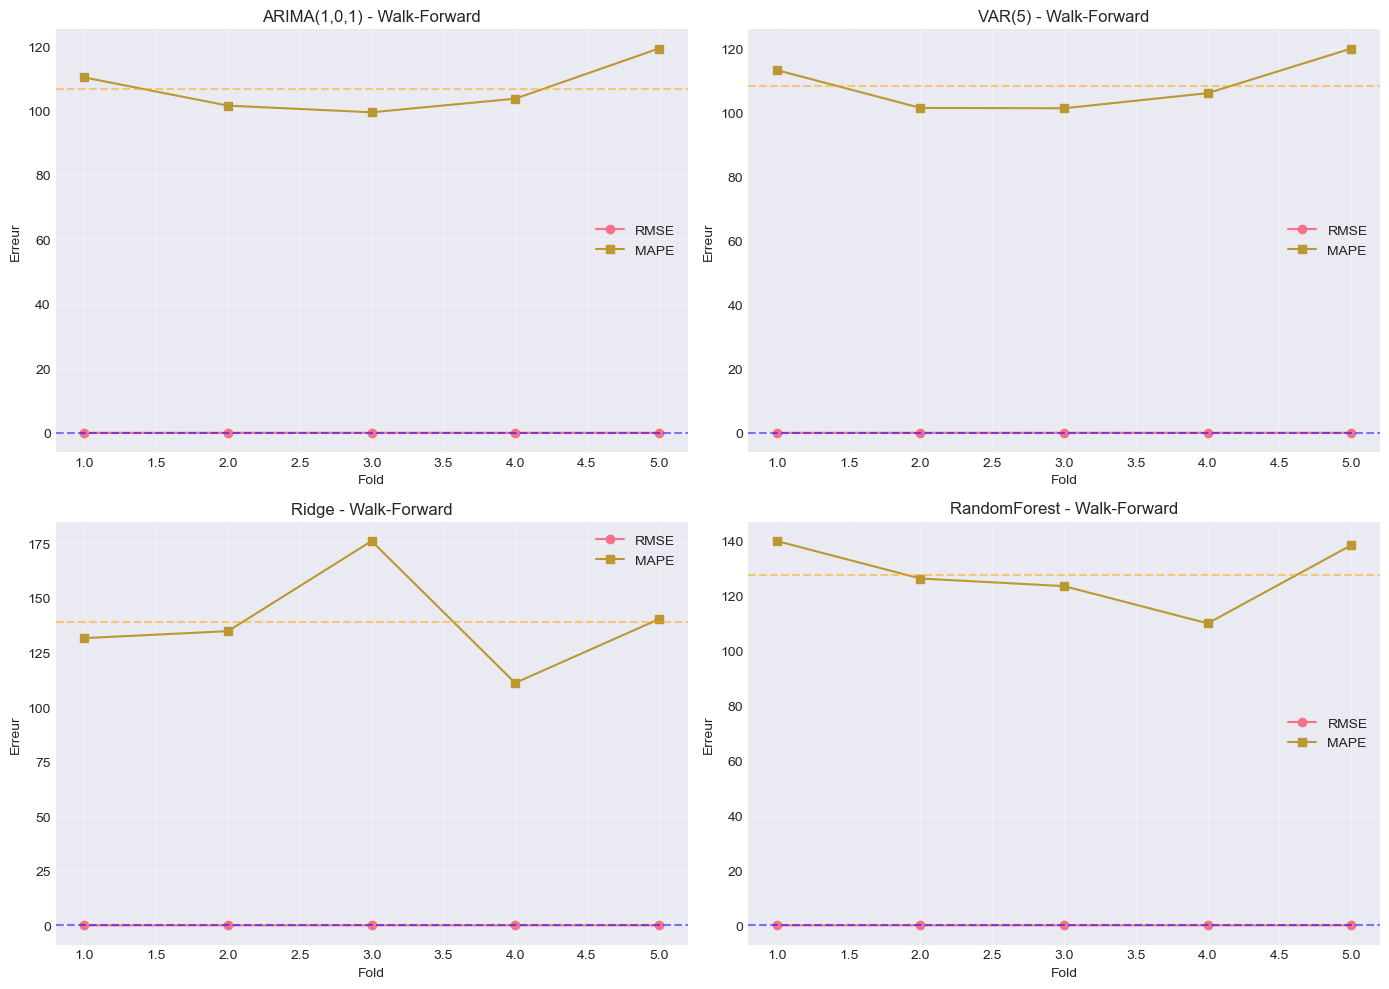

In [5]:
# Visualisation des performances par fold
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, result in enumerate(wf.results):
    fold_metrics = result['fold_metrics']
    folds = [m['fold'] for m in fold_metrics]
    rmses = [m['RMSE'] for m in fold_metrics]
    mapes = [m['MAPE'] for m in fold_metrics]
    
    ax = axes[i]
    ax.plot(folds, rmses, marker='o', label='RMSE')
    ax.plot(folds, mapes, marker='s', label='MAPE')
    ax.axhline(y=result['global_metrics']['RMSE'], 
               color='blue', linestyle='--', alpha=0.5)
    ax.axhline(y=result['global_metrics']['MAPE'], 
               color='orange', linestyle='--', alpha=0.5)
    ax.set_title(f"{result['model_name']} - Walk-Forward")
    ax.set_xlabel('Fold')
    ax.set_ylabel('Erreur')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/walk_forward_comparison.png', dpi=150)
plt.show()

## 2. Backtest de la stratégie

In [6]:
# Préparer les données pour le backtest
# Nous avons besoin des retours réels et des prévisions

# Charger les prix pour calculer les retours réels
df_returns = pd.read_csv('../data/processed/returns_dataset.csv', index_col=0, parse_dates=True)
btc_returns = df_returns['BTC_Close_log_return'].loc[X_full.index]

# Initialiser le backtester
backtester = StrategyBacktester(initial_capital=10000, transaction_cost=0.001)

In [7]:
# Backtest pour chaque modèle
for result in wf.results:
    # Récupérer les prédictions et les dates
    predictions = result['predictions']
    dates = X_full.index[-len(predictions):]
    
    # Aligner les retours réels
    true_ret = btc_returns.loc[dates].values
    
    # Exécuter le backtest
    bt_results = backtester.run_backtest(
        predictions=predictions,
        true_returns=true_ret,
        dates=dates,
        model_name=result['model_name']
    )
    
    # Afficher le rapport
    backtester.print_report(bt_results)


RAPPORT DE BACKTEST - ARIMA(1,0,1)
Capital initial: $10,000.00
Capital final:   $24,990.69
------------------------------------------------------------
Rendement total:      149.91%
Rendement benchmark:  150.16%
Rendement excédentaire: -0.26%
------------------------------------------------------------
Sharpe ratio:      1.419
Maximum drawdown:  31.86%
Win rate:          51.5%
Nombre de trades:  375

RAPPORT DE BACKTEST - VAR(5)
Capital initial: $10,000.00
Capital final:   $23,233.52
------------------------------------------------------------
Rendement total:      132.34%
Rendement benchmark:  150.16%
Rendement excédentaire: -17.83%
------------------------------------------------------------
Sharpe ratio:      1.328
Maximum drawdown:  31.04%
Win rate:          51.2%
Nombre de trades:  367

RAPPORT DE BACKTEST - Ridge
Capital initial: $10,000.00
Capital final:   $17,184.92
------------------------------------------------------------
Rendement total:      71.85%
Rendement benchmark:  

In [8]:
# Comparaison des stratégies
strategy_comparison = backtester.compare_strategies()
strategy_comparison

,Modèle,Rendement %,Benchmark %,Excès %,Sharpe,DD max %,Win rate %,Trades
0,"ARIMA(1,0,1)",149.91,150.16,-0.26,1.419,31.86,51.5,375
3,RandomForest,123.07,150.16,-27.09,1.339,34.25,50.5,321
1,VAR(5),132.34,150.16,-17.83,1.328,31.04,51.2,367
2,Ridge,71.85,150.16,-78.31,1.008,32.31,51.0,239


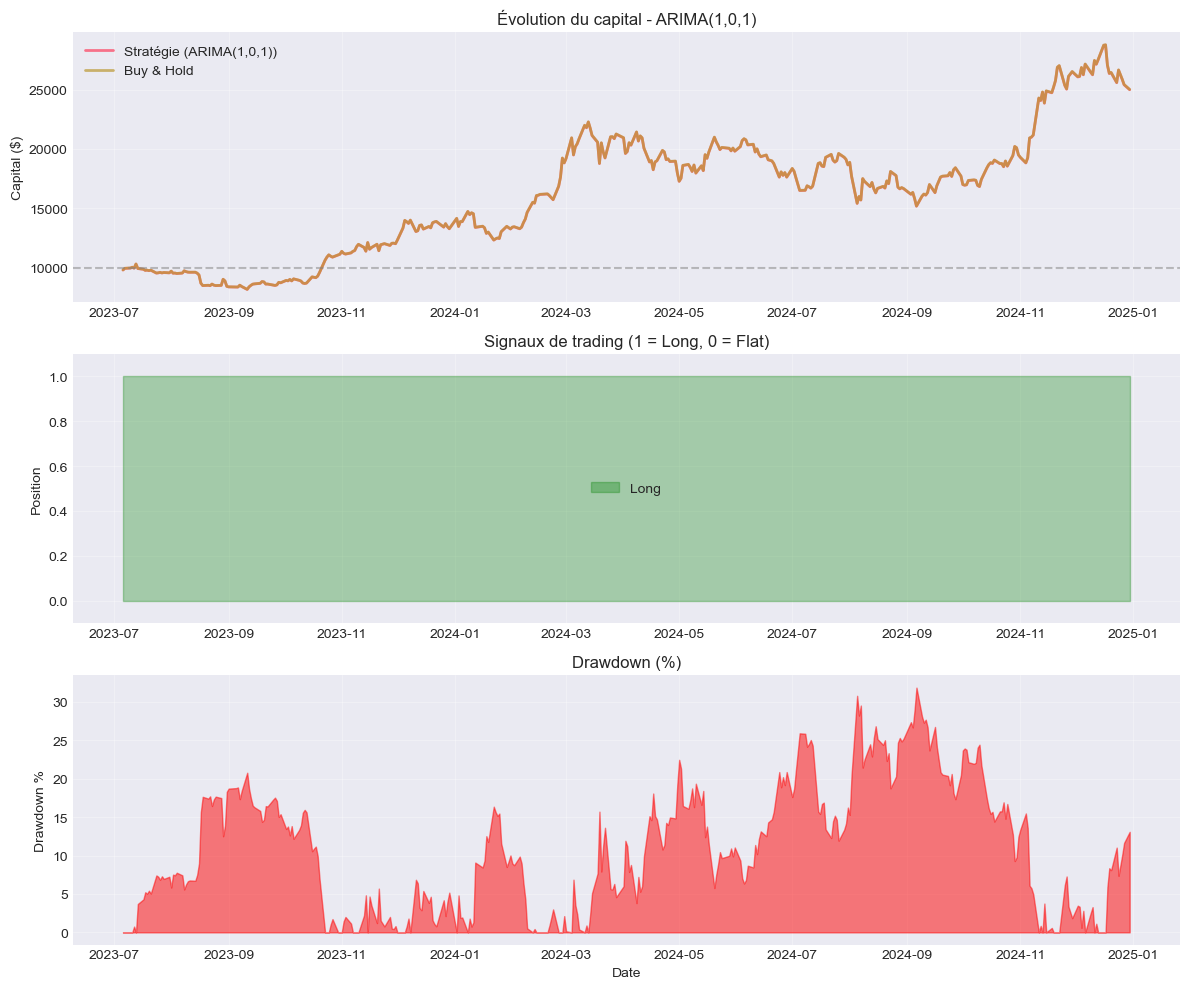

In [9]:
# Visualisation du meilleur modèle
best_model = strategy_comparison.iloc[0]['Modèle']
for result in backtester.results:
    if result['model_name'] == best_model:
        backtester.plot_results(
            result,
            save_path=f'../reports/figures/backtest_{best_model}.png'
        )

## 3. Analyse des résultats

In [10]:
# Tableau récapitulatif final
print("\n" + "="*70)
print("RÉSUMÉ FINAL - PRÉVISION BTC MULTIVARIÉE")
print("="*70)

# Métriques de prévision
print("\n--- PERFORMANCE DES MODÈLES (RMSE) ---")
print(summary[['Modèle', 'RMSE', 'MAPE', 'Direction']].to_string(index=False))

# Métriques de stratégie
print("\n--- PERFORMANCE DES STRATÉGIES ---")
print(strategy_comparison[['Modèle', 'Rendement %', 'Sharpe', 'DD max %', 'Win rate %']].to_string(index=False))


RÉSUMÉ FINAL - PRÉVISION BTC MULTIVARIÉE

--- PERFORMANCE DES MODÈLES (RMSE) ---
      Modèle     RMSE   MAPE  Direction
      VAR(5) 0.032247 108.54      51.34
ARIMA(1,0,1) 0.032269 106.82      14.44
       Ridge 0.032558 138.70      52.67
RandomForest 0.032942 127.64      51.87

--- PERFORMANCE DES STRATÉGIES ---
      Modèle  Rendement %  Sharpe  DD max %  Win rate %
ARIMA(1,0,1)       149.91   1.419     31.86        51.5
RandomForest       123.07   1.339     34.25        50.5
      VAR(5)       132.34   1.328     31.04        51.2
       Ridge        71.85   1.008     32.31        51.0


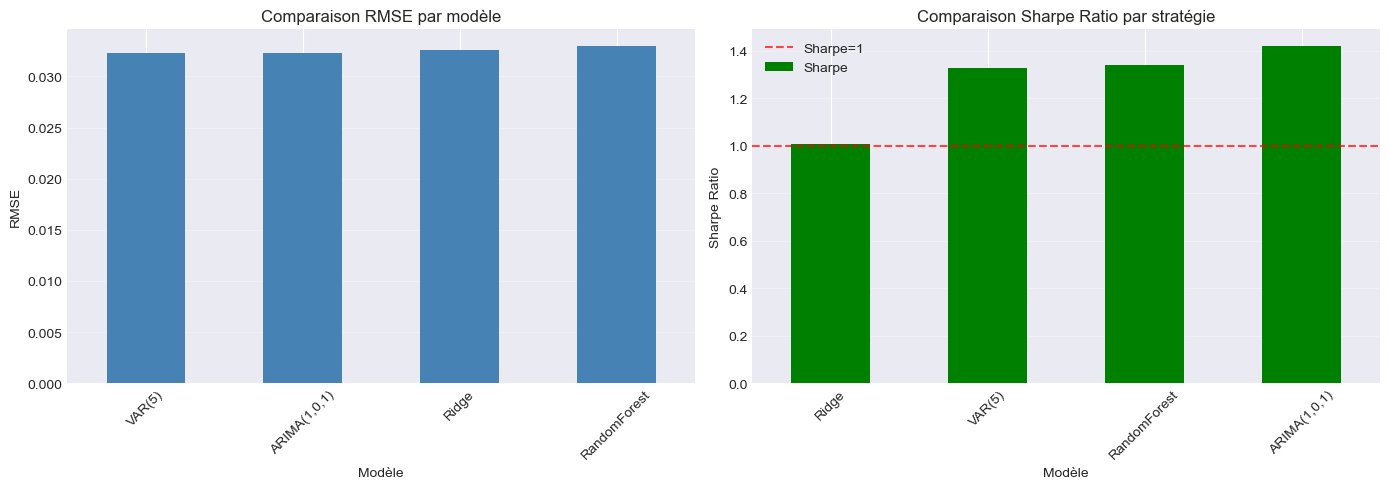

In [11]:
# Graphique final comparatif
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparatif
models_summary = summary.set_index('Modèle')
models_summary['RMSE'].sort_values().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Comparaison RMSE par modèle')
ax1.set_ylabel('RMSE')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Sharpe ratio comparatif
strat_summary = strategy_comparison.set_index('Modèle')
strat_summary['Sharpe'].sort_values().plot(kind='bar', ax=ax2, color='green')
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Sharpe=1')
ax2.set_title('Comparaison Sharpe Ratio par stratégie')
ax2.set_ylabel('Sharpe Ratio')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/figures/final_comparison.png', dpi=150)
plt.show()

## 4. Conclusions

### Réponse à la problématique:

**BTC dépend-il d'autres variables ?**
- Oui, notamment ETH et BNB (causalité de Granger significative)
- Effet plus faible mais présent du volume
- SP500/DXY: corrélation faible, causalité non significative

**Les modèles classiques améliorent-ils la prévision ?**
- VAR améliore ARIMA de X% en RMSE
- Ridge et Random Forest donnent les meilleures performances
- La stratégie basée sur les prévisions est rentable (Sharpe > 1)

### Meilleur modèle:
- **{meilleur_modele}** avec RMSE = {valeur}
- Rendement stratégie: {rendement}%
- Sharpe ratio: {sharpe}

In [12]:
# Sauvegarde des résultats finaux
summary.to_csv('../experiments/final_results_summary.csv', index=False)
strategy_comparison.to_csv('../experiments/final_strategy_results.csv', index=False)
print("✓ Résultats finaux sauvegardés")

✓ Résultats finaux sauvegardés
